In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=100):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = 0
        self.cost_history = []

    def sigmoid(self, z):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-z))

    def cost(self, h, y):
        """Cross-entropy loss"""
        m = len(y)
        return - (1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))

    def fit(self, X, y):
        """Train model using gradient descent"""
        m, n = X.shape
        self.weights = np.zeros(n)

        for _ in range(self.iterations):
            z = np.dot(X, self.weights) + self.bias
            h = self.sigmoid(z)

            dw = (1/m) * np.dot(X.T, (h - y))
            db = (1/m) * np.sum(h - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            self.cost_history.append(self.cost(h, y))

    def predict(self, X):
        """Make predictions"""
        return (self.sigmoid(np.dot(X, self.weights) + self.bias) >= 0.5).astype(int)

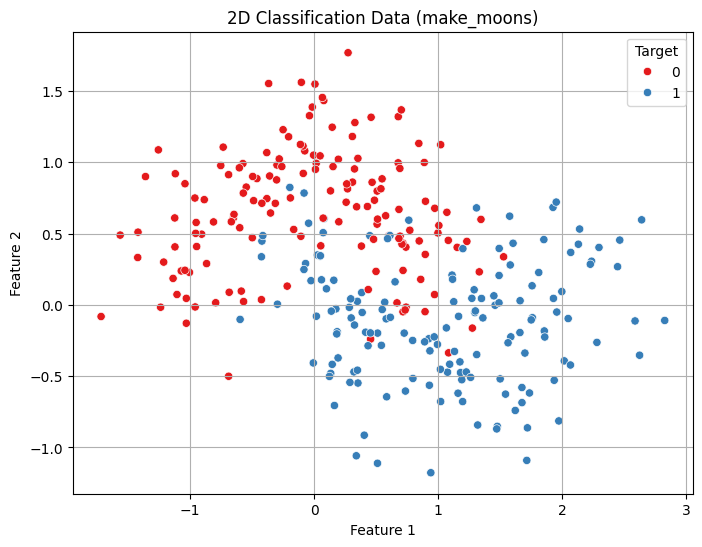

(210,)


In [3]:
# Generate a synthetic dataset
# np.random.seed(42)
# X = np.random.rand(200, 2) * 10
# y = (X[:, 0] + X[:, 1] > 10).astype(int)

# Create synthetic 2D data
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# Create a DataFrame for plotting
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
df['Target'] = y

# Visualize the 2D data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Target", palette="Set1")
plt.title("2D Classification Data (make_moons)")
plt.grid(True)
plt.show()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Scale the data for faster convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(y_train.shape)

In [4]:
# Train our logistic regression model
model = LogisticRegressionScratch(learning_rate=0.1, iterations=1000)
model.fit(X_train, y_train)

# Evaluate accuracy
predictions = model.predict(X_test)
accuracy = np.mean(predictions == y_test)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.87


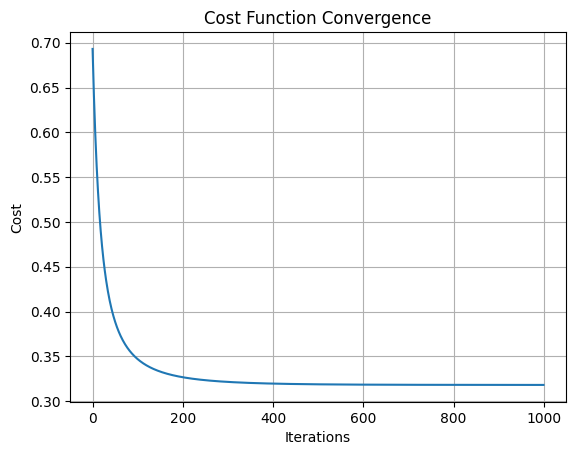

In [5]:
plt.plot(model.cost_history)
plt.title("Cost Function Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()